In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/dataset_maestro.csv')

df.head()

df['tipo_propiedad'].value_counts()

df.columns.tolist()

# df.isna().sum()

# df[df.operacion == 'alquiler'].groupby('barrio')['barrio'].value_counts().sort_values()

# df[(df.barrio == 'versalles') & (df.operacion == 'alquiler')].ambientes

df[df.ambientes == 1].groupby(['precio_moneda','operacion']).precio_valor.median()

df[(df.precio_moneda == 'ARS') & (df.operacion == 'venta')]

df[df.operacion == 'alquiler'].groupby(['barrio','precio_moneda'])['precio_valor'].median()

barrio            precio_moneda
agronomia         ARS              800000.0
                  USD                5500.0
almagro           ARS              700000.0
                  USD                1050.0
balvanera         ARS              600000.0
                                     ...   
villa santa rita  ARS              800000.0
                  USD                3000.0
villa soldati     ARS              650000.0
villa urquiza     ARS              900000.0
                  USD                3000.0
Name: precio_valor, Length: 85, dtype: float64

In [46]:

df.columns.tolist()

['portal',
 'id_aviso',
 'url',
 'fecha_scraping',
 'operacion',
 'tipo_propiedad',
 'precio_valor',
 'precio_moneda',
 'precio_texto',
 'expensas_valor',
 'expensas_moneda',
 'direccion',
 'calle',
 'altura',
 'piso',
 'barrio',
 'barrio_raw',
 'comuna',
 'localidad',
 'latitud',
 'longitud',
 'sup_total_m2',
 'sup_cubierta_m2',
 'ambientes',
 'dormitorios',
 'banos',
 'cocheras',
 'antiguedad_anios',
 'es_a_estrenar',
 'precio_m2',
 'titulo',
 'descripcion',
 'detalles',
 'amenities',
 'pileta',
 'parrilla',
 'gimnasio',
 'sum',
 'losa_radiante',
 'aire_acondicionado',
 'apto_credito',
 'apto_profesional',
 'cochera_txt',
 'baulera',
 'seguridad',
 'luminoso',
 'balcon',
 'a_reciclar',
 'reciclado',
 'credito_uva',
 'frente',
 'amoblado',
 'patio_jardin',
 'ascensor',
 'profesional_renta']

In [34]:
df[(df.operacion == 'alquiler') & (df.barrio == 'agronomia')]

,portal,id_aviso,url,fecha_scraping,operacion,tipo_propiedad,precio_valor,precio_moneda,precio_texto,expensas_valor,...,luminoso,balcon,a_reciclar,reciclado,credito_uva,frente,amoblado,patio_jardin,ascensor,profesional_renta
264,remax,5900fabf-8966-46bf-ba1a-e98fc4a637b6,https://www.remax.com.ar/listings/departamento...,2026-08-13T22:41:33+00:00,alquiler,departamento_estandar,800000.0,ARS,ARS 800000.0,74000.0,...,0,0,0,0,0,0,0,0,0,0
1542,remax,e8821a9b-b0b7-43ea-a846-4076b9a24bfb,https://www.remax.com.ar/listings/alquiler-loc...,2026-08-13T22:31:53+00:00,alquiler,local,5500.0,USD,USD 5500.0,NaN,...,0,0,0,0,0,0,0,0,0,0


In [50]:
df.value_counts()

portal  id_aviso                              url                                                                                   fecha_scraping             operacion  tipo_propiedad             precio_valor  precio_moneda  precio_texto  expensas_valor  expensas_moneda  direccion                                         calle                                altura  piso    barrio         barrio_raw     comuna  localidad        latitud     longitud    sup_total_m2  sup_cubierta_m2  ambientes  dormitorios  banos  cocheras  antiguedad_anios  es_a_estrenar  precio_m2  titulo                                              descripcion                                                                                                                                                                                                                                                                                                                                                                              

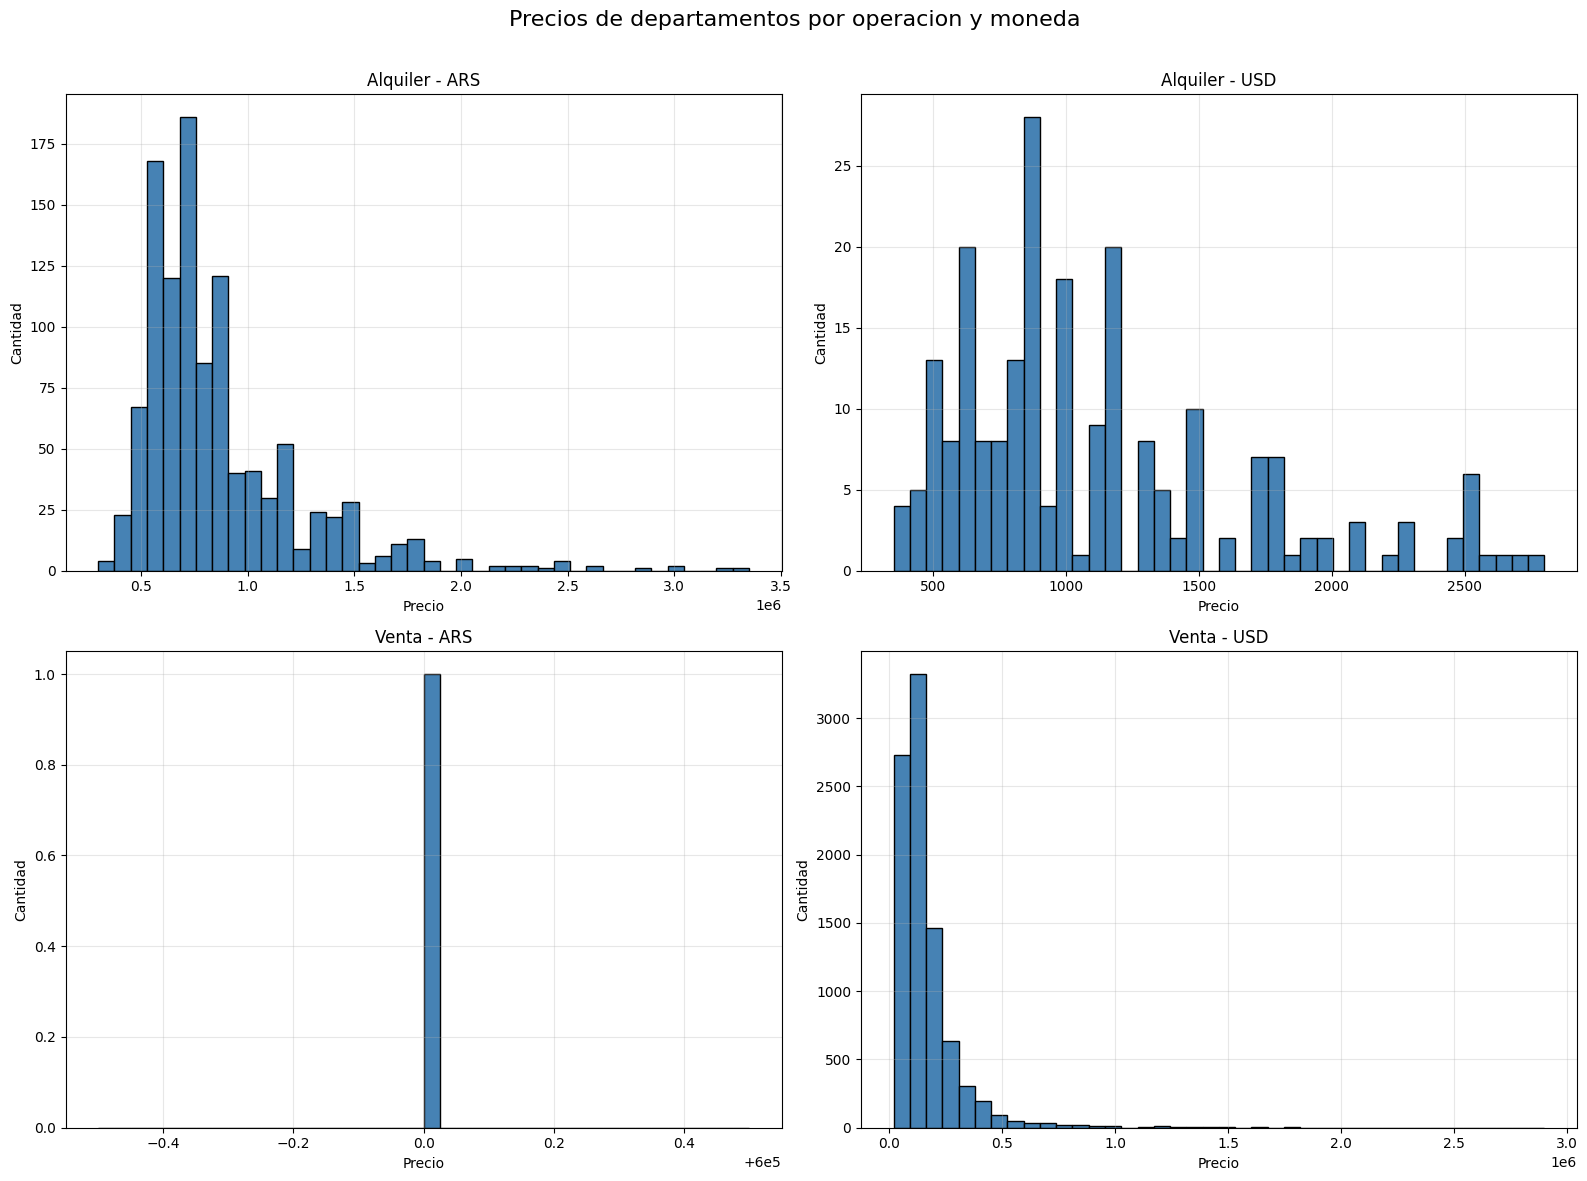

In [45]:
import matplotlib.pyplot as plt

deptos = df[df['tipo_propiedad'].str.contains('departamento', case=False, na=False)].copy()
deptos = deptos[deptos['precio_valor'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Precios de departamentos por operacion y moneda', fontsize=16)

config = [
    ('alquiler', 'ARS', axes[0, 0]),
    ('alquiler', 'USD', axes[0, 1]),
    ('venta', 'ARS', axes[1, 0]),
    ('venta', 'USD', axes[1, 1]),
]

for operacion, moneda, ax in config:
    subset = deptos[
        (deptos['operacion'] == operacion) &
        (deptos['precio_moneda'] == moneda)
    ].copy()

    precios = subset['precio_valor'].dropna()

    # Quitar outliers solo del histograma de alquiler en USD
    if (operacion == 'alquiler') and (moneda == 'USD') and not precios.empty:
        q1 = precios.quantile(0.25)
        q3 = precios.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        precios = precios[(precios >= lower_bound) & (precios <= upper_bound)]

    if precios.empty:
        ax.text(0.5, 0.5, f'Sin datos\n{operacion} / {moneda}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    ax.hist(precios, bins=40, color='steelblue', edgecolor='black')
    ax.set_title(f'{operacion.title()} - {moneda}')
    ax.set_xlabel('Precio')
    ax.set_ylabel('Cantidad')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [58]:
df['sup_total_m2'].dropna().sort_values(ascending=False)

## El de 194000 m2 esta mal tipeado (14106)
## El 116012 tambien
## El 6442 tambien
## El 363 tambien
## El 677 tambien

14106    194000.0
361      173000.0
11610    140008.0
6440     105297.0
675       75000.0
           ...   
11099         0.0
12842         0.0
12038         0.0
13307         0.0
996           0.0
Name: sup_total_m2, Length: 14867, dtype: float64

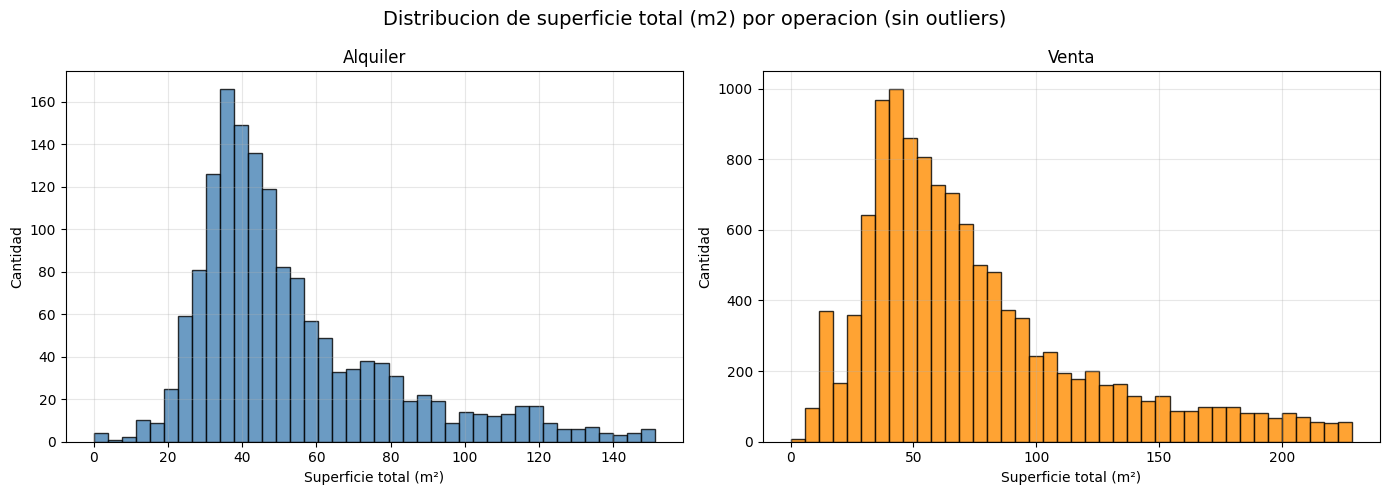

In [71]:
# Calcular Q1, Q3 e IQR
# Calcular Q1, Q3 e IQR
datos = df['sup_total_m2'].dropna()
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1

# Definir límites
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filtrar datos sin outliers
datos_sin_outliers = datos[(datos >= lower_bound) & (datos <= upper_bound)]

# Recrear el gráfico sin outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribucion de superficie total (m2) por operacion (sin outliers)', fontsize=14)

for ax, operacion, color in zip(
    axes,
    ['alquiler', 'venta'],
    ['steelblue', 'darkorange']
):
    datos_filtrados = df.loc[df['operacion'] == operacion, 'sup_total_m2'].dropna()
    
    # Aplicar filtro de outliers
    q1_op = datos_filtrados.quantile(0.25)
    q3_op = datos_filtrados.quantile(0.75)
    iqr_op = q3_op - q1_op
    lower = q1_op - 1.5 * iqr_op
    upper = q3_op + 1.5 * iqr_op
    datos_filtrados = datos_filtrados[(datos_filtrados >= lower) & (datos_filtrados <= upper)]
    
    ax.hist(datos_filtrados, bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(operacion.title())
    ax.set_xlabel('Superficie total (m²)')
    ax.set_ylabel('Cantidad')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df[df.operacion == 'alquiler'].precio_m2.groupby(df.precio_moneda).median()

# ver diferencia de precio x m2 en dolares

precio_moneda
ARS    17981.225
USD       15.690
Name: precio_m2, dtype: float64

In [51]:
df[(df.operacion == 'alquiler') & (df.precio_moneda == 'USD') & (df.precio_m2 > 50)].precio_m2

# solucionar tema de alquileres en dolares que en realidad son en pesos

111     10909.09
535       936.60
609        55.65
817        74.50
1222    21666.67
1675     5577.56
Name: precio_m2, dtype: float64

In [ ]:
df[(df.operacion == 'alquiler') & (df.precio_moneda == 'USD')].precio_m2.mean()

np.float64(109.47033412887828)

In [4]:
# Lectura dataset limpio

df = pd.read_csv('../data/processed/dataset_limpio.csv')

In [4]:
df.operacion.value_counts()

operacion
venta       10749
alquiler     1348
Name: count, dtype: int64

In [6]:
df = pd.read_csv('../data/processed/ventas_con_rentabilidad.csv')

df.head()

,id_aviso,url,fecha_scraping,operacion,tipo_propiedad,precio_valor,precio_moneda,expensas_valor,expensas_moneda,direccion,...,alquiler_est_usd_mes,alquiler_est_m2,n_alq_barrio,estimacion_confiable,rent_bruta_pct,rent_neta_pct,meses_repago,error_estimacion,rent_bruta_min,rent_bruta_max
0,3813fc6f-ce41-4492-b0a4-af05c64277f3,https://www.remax.com.ar/listings/dpto-mono-en...,2026-08-17T01:55:51+00:00,venta,departamento_estandar,70000.0,USD,100000.0,ARS,Avenida Pavón 3300,...,440.71,12.38,8,0,7.56,6.12,159.0,0.100280,6.80,8.32
1,38233170-9f47-4df8-bbe5-2f2c112f084d,https://www.remax.com.ar/listings/venta-2-ambi...,2026-08-17T01:55:49+00:00,venta,departamento_estandar,205000.0,USD,0.0,ARS,Avenida Corrientes 5100,...,828.80,12.21,39,1,4.85,3.93,247.0,0.127680,4.23,5.47
2,3829c155-d1a7-4aa1-b2bc-e6f03c5aa7bb,https://www.remax.com.ar/listings/departamento...,2026-08-17T01:55:47+00:00,venta,departamento_estandar,398000.0,USD,0.0,ARS,Avellaneda 2300,...,1603.32,13.14,47,1,4.83,3.91,248.0,0.179516,3.96,5.70
3,382a925d-fe4a-4e80-b0d3-e973437944ad,https://www.remax.com.ar/listings/dpto-2-amb-e...,2026-08-17T01:55:46+00:00,venta,departamento_estandar,89000.0,USD,0.0,ARS,José Bonifacio 2700,...,499.05,12.13,47,1,6.73,5.45,178.0,0.100280,6.06,7.40
4,383795cf-4c44-4828-b46e-35d8b24849b7,https://www.remax.com.ar/listings/2-ambientes-...,2026-08-17T01:55:45+00:00,venta,departamento_estandar,83000.0,USD,152000.0,ARS,Bulnes 1400,...,596.58,12.18,254,1,8.63,6.99,139.0,0.100280,7.76,9.50


In [7]:
df[df['sup_total_m2'] > 100].rent_neta_pct.median()
df[(70 < df['sup_total_m2']) & (df['sup_total_m2'] <= 100 )].rent_neta_pct.median()
df[(50 < df['sup_total_m2']) & (df['sup_total_m2'] <= 70)].rent_neta_pct.median()
df[(35 < df['sup_total_m2']) & (df['sup_total_m2'] <= 50 )].rent_neta_pct.median()
df[df['sup_total_m2'] <= 35].rent_neta_pct.median()

np.float64(5.825)